Khalid Waleed Alhilal
2230000788
8m02

# LAB5


### Import necessary libraries as specified in the lab session

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

def plot_images(images, titles, figsize=(15, 5)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    for i, ax in enumerate(axes):
        # Convert grayscale to display properly or show RGB directly
        if len(images[i].shape) == 2:
            ax.imshow(images[i], cmap='gray')
        else:
            ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

#### Task 1: Box Filter "Convolve an image with a 7x7 box filter"

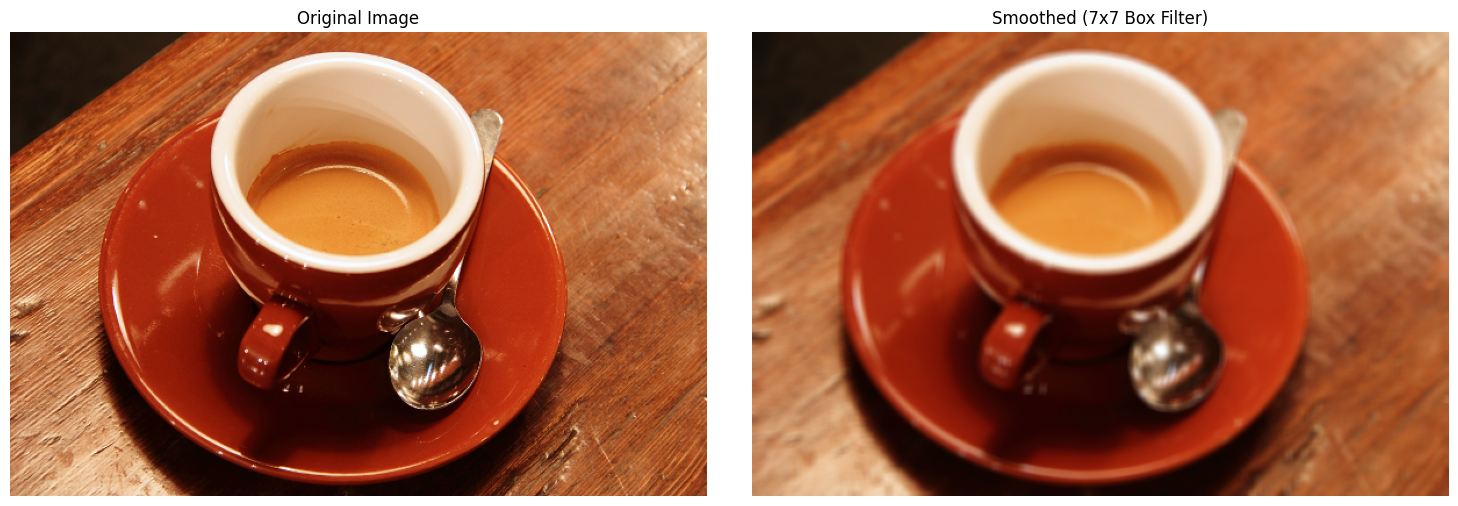

In [3]:
# ه use the coffee img from skimage
image_t1 = data.coffee()

# Apply Smoothing in 7x7 Box Filter 
# cv2.blur automatically applies a normalized box filter
smoothed_box = cv2.blur(image_t1, (7, 7))

# Output the original and smoothed img
plot_images([image_t1, smoothed_box], 
            ['Original Image', 'Smoothed (7x7 Box Filter)'])

#### Task 2: Gaussian Filters "Apply 5x5 and 21x21 Gaussian filters"

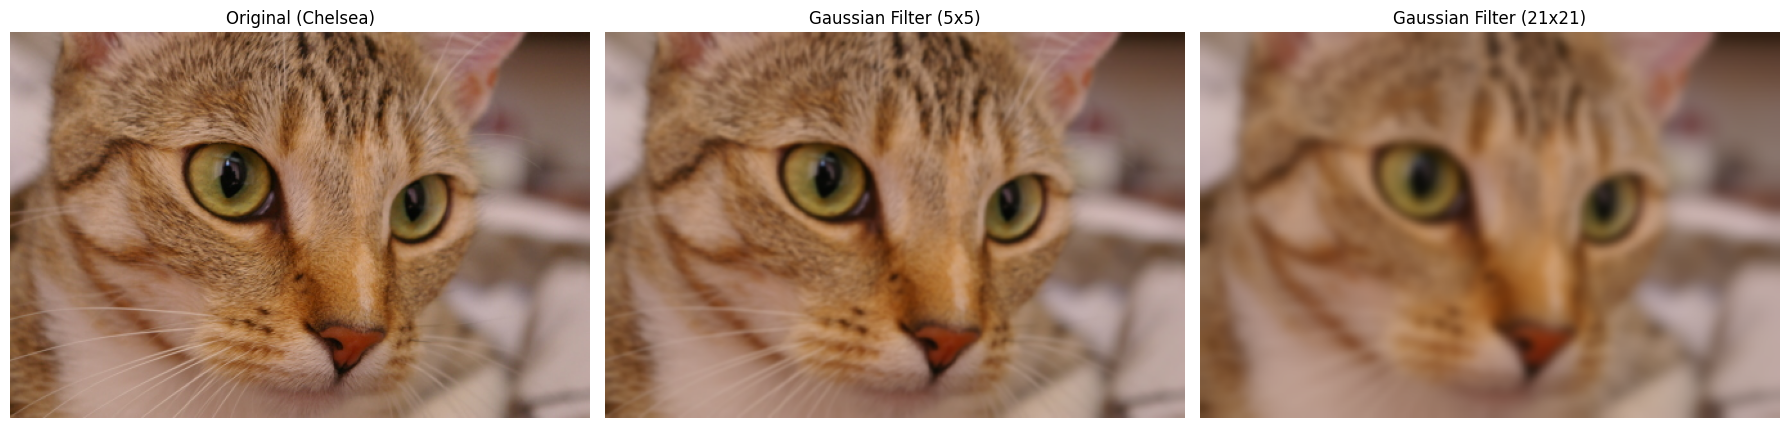

In [4]:
# Using the cat image (Chelsea)
image_t2 = data.chelsea() 

# Apply 5x5 Gaussian Filter
gaussian_5x5 = cv2.GaussianBlur(image_t2, (5, 5), 0)

# Apply 21x21 Gaussian Filter
gaussian_21x21 = cv2.GaussianBlur(image_t2, (21, 21), 0)

# Show the three images "the original , 5x5 Gaussian Filter and 21x21 Gaussian Filter"
plot_images([image_t2, gaussian_5x5, gaussian_21x21], 
            ['Original (Chelsea)', 'Gaussian Filter (5x5)', 'Gaussian Filter (21x21)'],
            figsize=(18, 6))

#### Task 3: Laplacian Filter for Sharpening "Apply a 3x3 Laplacian filter to sharpen the image"

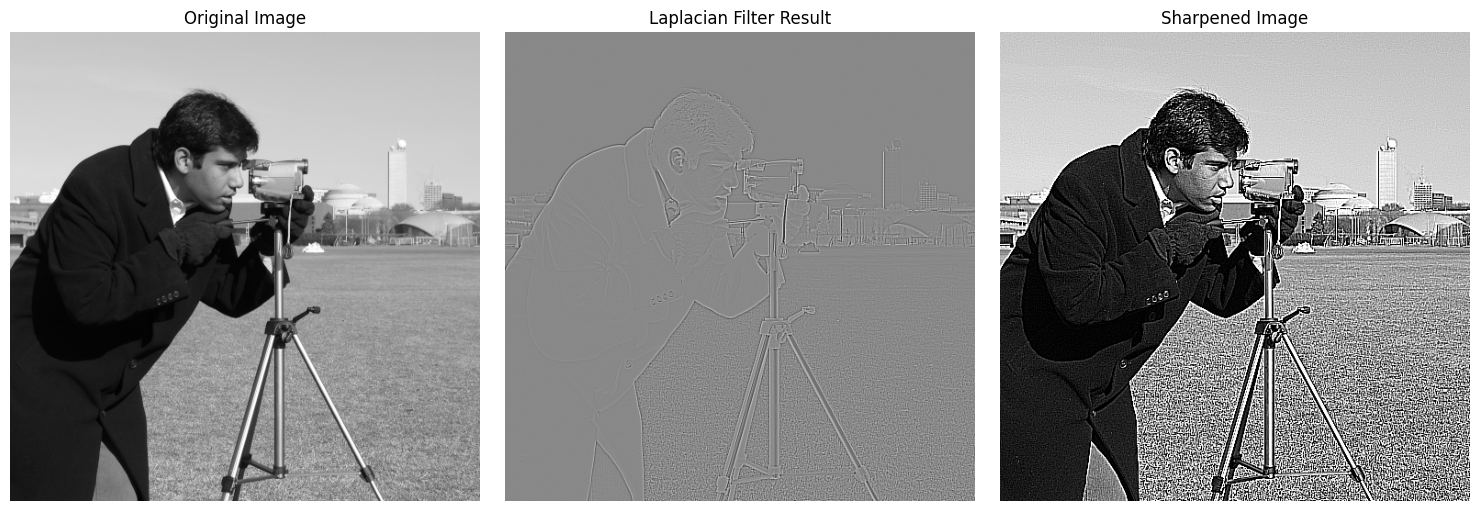

In [5]:
# It is better to use a grayscale image to clearly see the Laplacian edges
image_t3 = data.camera()

# St1: Convert image to float32 (between 0 and 1)
image_float = image_t3.astype(np.float32) / 255.0

# St2: Use cv2.Laplacian() function with a 3x3 kernel
# I use cv2.CV_32F to avoid overflow/underflow that happens with standard 8-bit depth
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

# St3: Sharpen the image
# Subtracting the Laplacian from the original image enhances the edges
sharpened = np.clip(image_float - laplacian, 0, 1)

# St4: Plot the original, Laplacian result, and sharpened img
plot_images([image_float, laplacian, sharpened], 
            ['Original Image', 'Laplacian Filter Result', 'Sharpened Image'])